In [2]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

In [73]:
# Generate sensor data (e.g., temperature readings)
def generate_sensor_data(n_samples=200):
    time = np.linspace(0, 10, n_samples)
    data = np.sin(time*2) + np.random.normal(0, 0.3, n_samples)
    return data

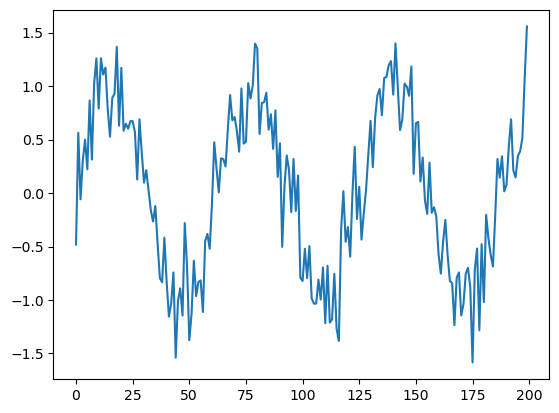

In [74]:
data = generate_sensor_data()

plt.plot(data)

In [75]:
# Simple Seq2Seq for time series
class TimeSeriesSeq2Seq(nn.Module):
    def __init__(self, hidden_dim=32):
        super().__init__()
        self.encoder_rnn = nn.GRU(1, hidden_dim, batch_first=True)
        self.decoder_rnn = nn.GRU(1, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)
    
    def forward(self, src, trg_len):
        # Encode
        _, hidden = self.encoder_rnn(src)
        
        # Decode
        batch_size = src.shape[0]
        decoder_input = src[:, -1:, :]  # Start with last input value
        outputs = []
        
        for _ in range(trg_len):
            out, hidden = self.decoder_rnn(decoder_input, hidden)
            prediction = self.fc(out)
            outputs.append(prediction)
            decoder_input = prediction  # Use prediction as next input
        
        return torch.cat(outputs, dim=1)

In [ ]:
# Prepare data: use input_len past values to predict output_len future values
sensor_data = generate_sensor_data()
input_len, output_len = 60, 100

X, y = [], []
for i in range(len(sensor_data) - input_len - output_len):
    X.append(sensor_data[i:i+input_len])
    y.append(sensor_data[i+input_len:i+input_len+output_len])

X = torch.FloatTensor(X).unsqueeze(-1)  # Shape: [samples, 10, 1]
y = torch.FloatTensor(y).unsqueeze(-1)  # Shape: [samples, 5, 1]

In [77]:
# Train
model = TimeSeriesSeq2Seq()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.MSELoss()

for epoch in range(50):
    optimizer.zero_grad()
    predictions = model(X, output_len)
    loss = criterion(predictions, y)
    loss.backward()
    optimizer.step()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {loss.item():.4f}')

# Test prediction
test_input = X[0:1]  # Take first sequence
prediction = model(test_input, output_len)
print(f'\nInput: {test_input[0, :, 0].detach().numpy()}')
print(f'Predicted: {prediction[0, :, 0].detach().numpy()}')
print(f'Actual: {y[0, :, 0].numpy()}')

Epoch 10, Loss: 0.4758
Epoch 20, Loss: 0.4402
Epoch 30, Loss: 0.3074
Epoch 40, Loss: 0.2673
Epoch 50, Loss: 0.1095

Input: [ 0.28173572 -0.8310661  -0.01493156 -0.00929882  0.5963533   0.24163994
  0.4532654   0.96695435  0.84283763  0.667829    0.8525762   0.8966865
  0.9874979   1.1197758   0.5367618   0.8418614   0.99719465  0.51343805
  0.93406534  0.690547    0.72716236  0.70316553  0.89352787  1.1267023
  0.8076005   0.9093308   1.1180927  -0.02958069 -0.01038983  0.5614177
 -0.44167912  0.11773465  0.07041962 -0.3407797  -0.12944598 -0.3281647
 -0.32581127 -0.65374696 -0.7129465  -0.79260224 -0.55390066 -0.89556587
 -0.5635129  -0.82095253 -1.1293832  -1.1529634  -1.2414619  -0.75292224
 -0.5637181  -0.92408276 -0.5632315  -1.3577536  -0.9806803  -0.9775905
 -0.36682716 -0.32353055 -0.37382227 -0.90999734 -0.7885436  -0.23159204]
Predicted: [-0.17614537 -0.06091879  0.04679009  0.14276087  0.22949854  0.30925557
  0.38369915  0.4540585   0.52110565  0.5849793   0.6450124   0.699

In [78]:
prediction.shape, y.shape

(torch.Size([1, 100, 1]), torch.Size([40, 100, 1]))

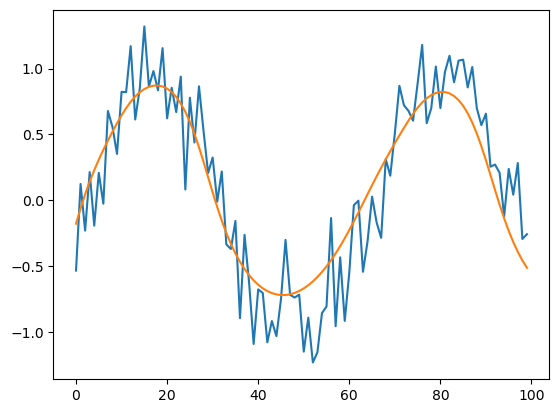

In [79]:
import matplotlib.pyplot as plt

with torch.no_grad():
    plt.plot(y[0,:])
    plt.plot(prediction[0,:])